# Data Pre-Processing

In [132]:
# Libraries
import pandas as pd
import scipy.stats as stats

In [133]:
# Load dataset
df = pd.read_csv("/content/sample_data/cellphone_data.csv")

# Perform Other Data Pre-processing steps below such as checking data description, null values etc.

In [131]:
#Checking data description
df.describe()

,user_id,cellphone_id,rating,internal memory,RAM,performance,main camera,selfie camera,battery size,screen size,weight,price(INR),Salary_in_INR,age
count,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000
mean,136.373737,16.421212,6.691919,145.034343,6.701010,6.013869,42.238384,15.368687,4376.201010,6.452323,198.159596,52641.698081,527464.393939,36.393939
std,80.664654,9.473466,2.616552,89.314731,2.666782,2.867455,26.694386,9.860320,763.260773,0.420758,23.731792,36775.360069,92676.123930,9.634176
min,0.000000,0.000000,1.000000,32.000000,3.000000,1.020000,12.000000,4.000000,2018.000000,4.700000,141.000000,11268.150000,300000.000000,21.000000
25%,74.000000,8.000000,5.000000,128.000000,4.000000,3.790000,12.000000,8.000000,4000.000000,6.400000,183.000000,26117.650000,459375.000000,29.000000
50%,128.000000,16.000000,7.000000,128.000000,8.000000,6.820000,50.000000,12.000000,4600.000000,6.500000,203.000000,43675.000000,486150.000000,33.000000
75%,226.000000,25.000000,9.000000,128.000000,8.000000,7.940000,50.000000,16.000000,5000.000000,6.700000,207.000000,73374.000000,601500.000000,42.000000
max,258.000000,32.000000,10.000000,512.000000,12.000000,11.000000,108.000000,40.000000,5003.000000,7.600000,271.000000,174525.300000,700500.000000,61.000000


In [134]:
#Checking for null values
df.isnull().sum()

,0
user_id,0
cellphone_id,0
rating,0
brand,0
model,0
operating system,0
internal memory,0
RAM,0
performance,0
main camera,0


In [135]:
#Checking for number of rows and columns
df.shape

(990, 22)

In [136]:
#Checking for duplicate rows
df.duplicated().sum()

np.int64(0)

## Split the variables in the dataset into numerical and categorical types.

In [138]:
# Numerical variables
numerical_vars = df.select_dtypes(include=['int64', 'float64'])
print("Numerical Variables:")
print(numerical_vars.columns)

# Categorical variables
categorical_vars = df.select_dtypes(include=['object'])
print("\nCategorical Variables:")
print(categorical_vars.columns)

Numerical Variables:
Index(['user_id', 'cellphone_id', 'rating', 'internal memory', 'RAM',
       'performance', 'main camera', 'selfie camera', 'battery size',
       'screen size', 'weight', 'price(INR)', 'Salary_in_INR', 'age'],
      dtype='object')

Categorical Variables:
Index(['brand', 'model', 'operating system', 'release date', 'user_name',
       'Region(City)', 'gender', 'occupation'],
      dtype='object')


## Create boxplots for all numerical variables to check for outliers.

user_id              int64
cellphone_id         int64
rating               int64
internal memory      int64
RAM                  int64
performance        float64
main camera          int64
selfie camera        int64
battery size         int64
screen size        float64
weight               int64
price(INR)         float64
Salary_in_INR        int64
age                  int64
dtype: object


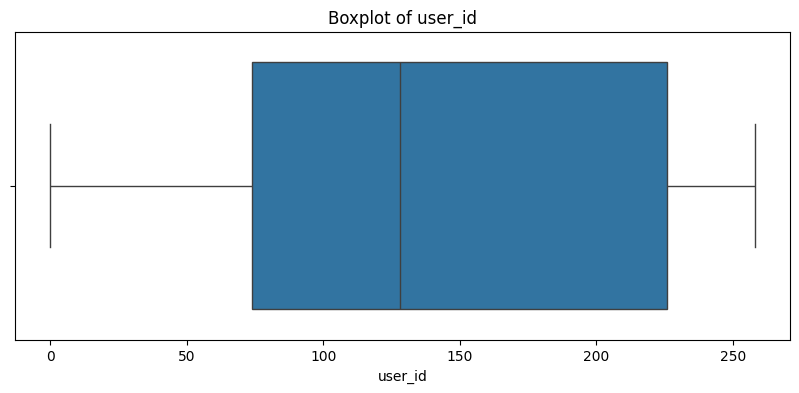

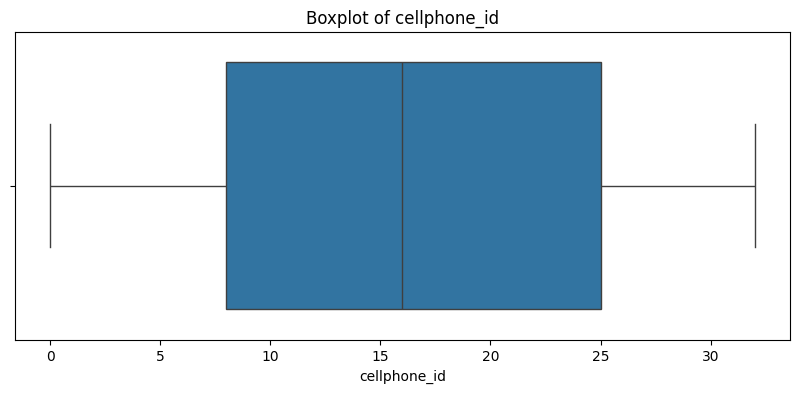

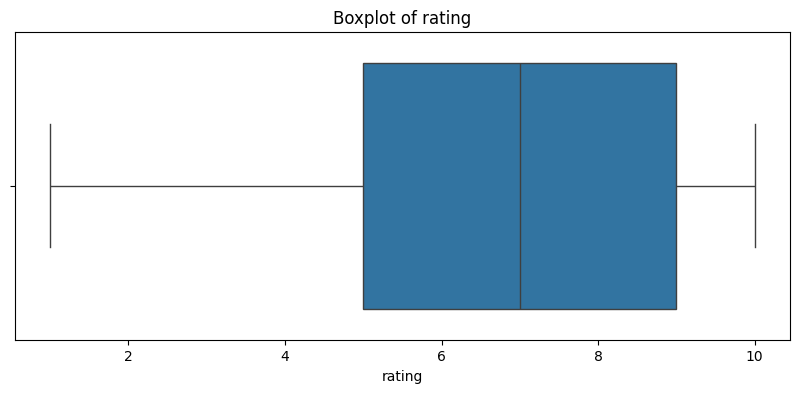

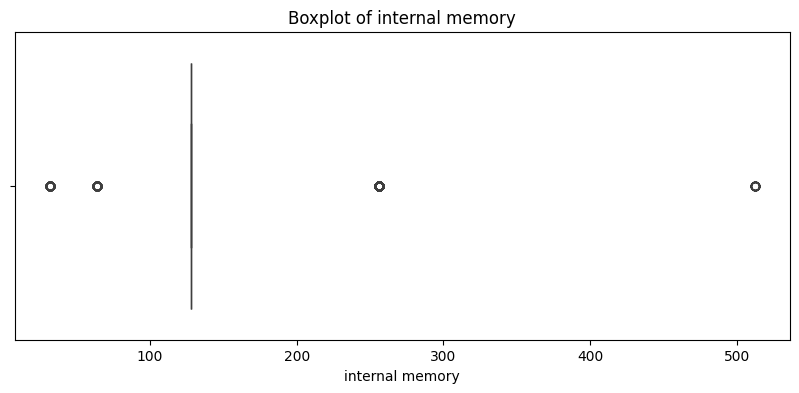

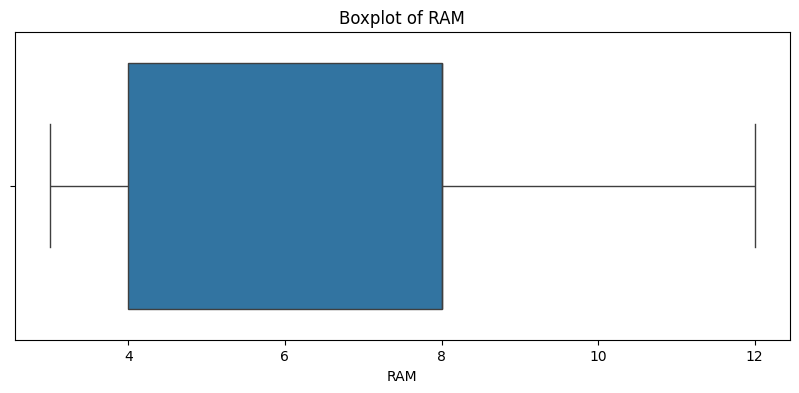

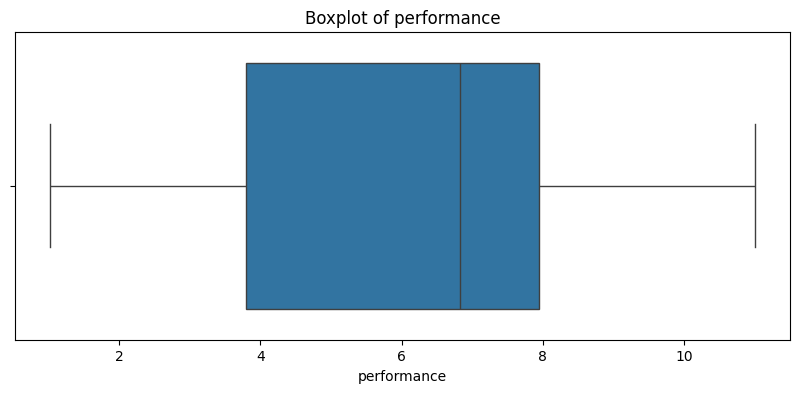

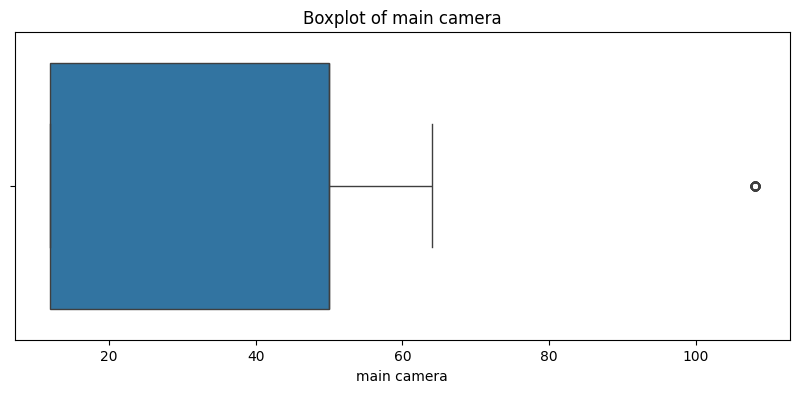

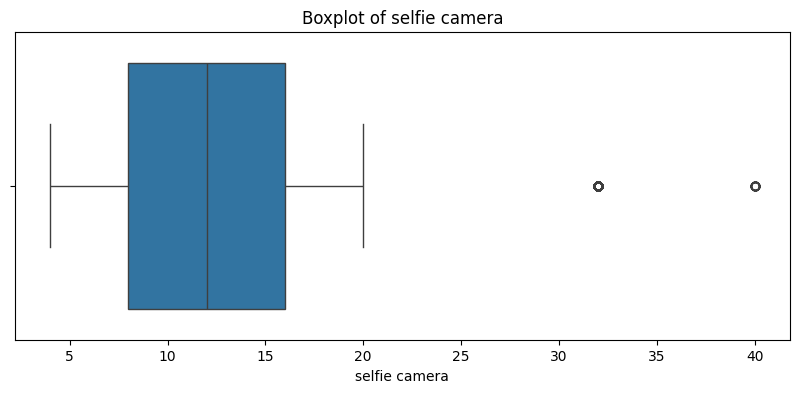

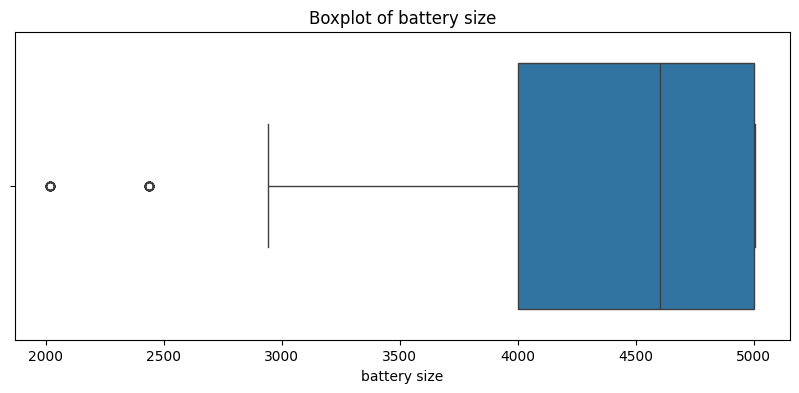

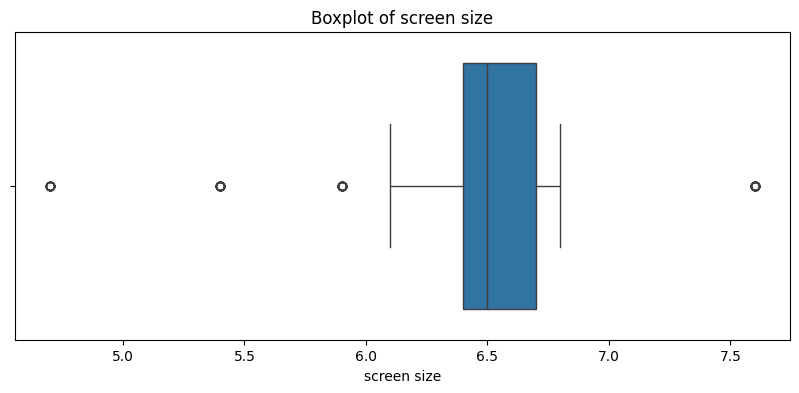

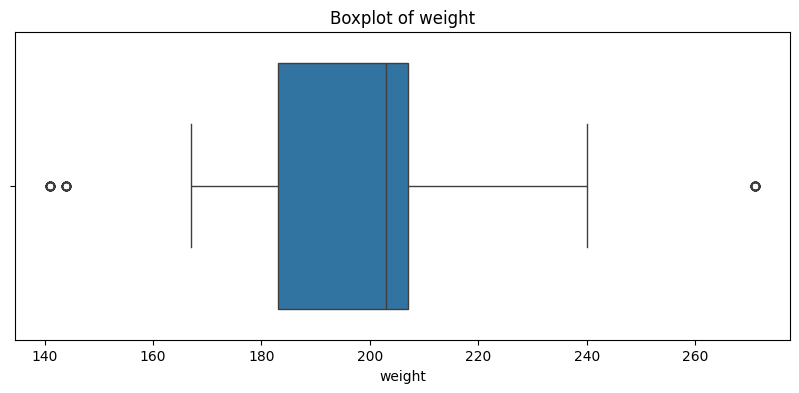

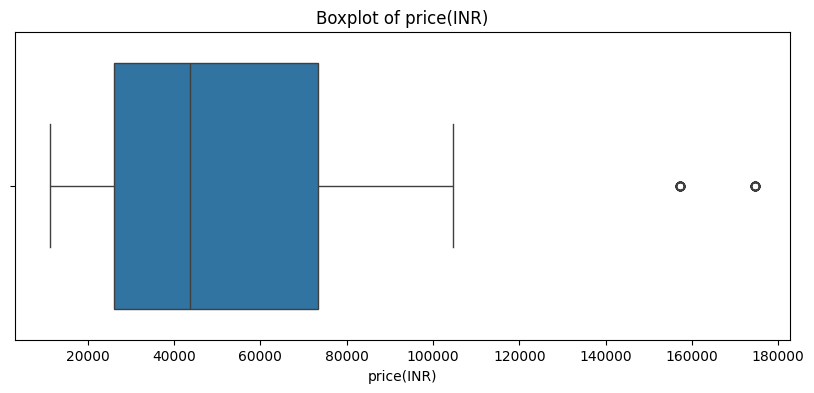

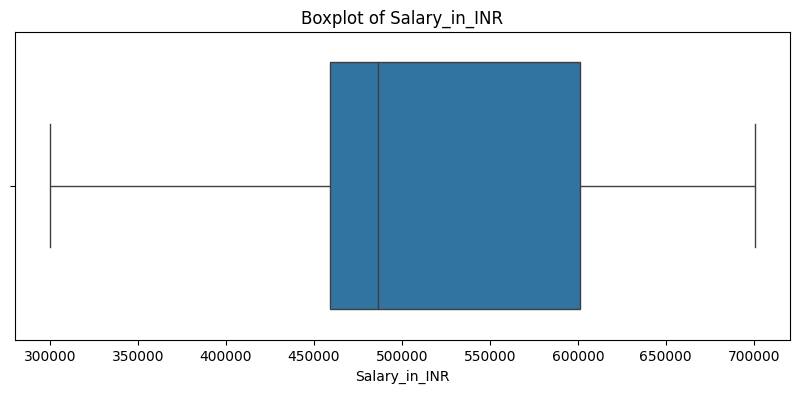

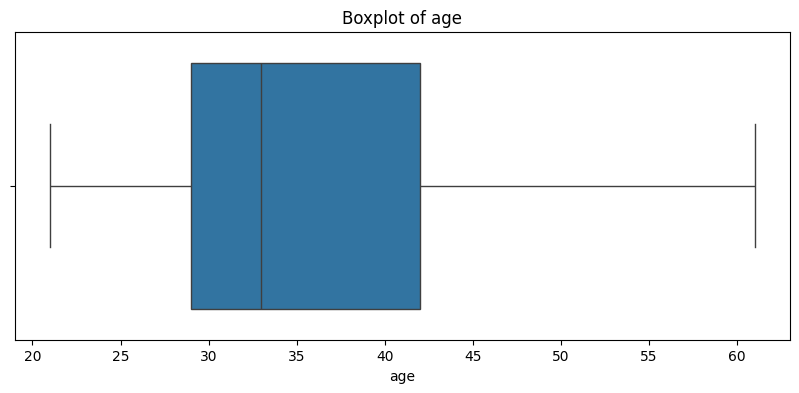

In [139]:
#Printing all the numerical variables and creating boxplot for each columns to check for outliers
import matplotlib.pyplot as plt
import seaborn as sns
numerical_variables = df.select_dtypes(include=['int64', 'float64'])
print(numerical_variables.dtypes)
numerical_cols = ["user_id", "cellphone_id", "rating", "internal memory",
                  "RAM", "performance", "main camera",
                  "selfie camera", "battery size", "screen size", "weight", "price(INR)", "Salary_in_INR", "age"]

for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

## Generate a heatmap for all numerical variables to examine their correlations.

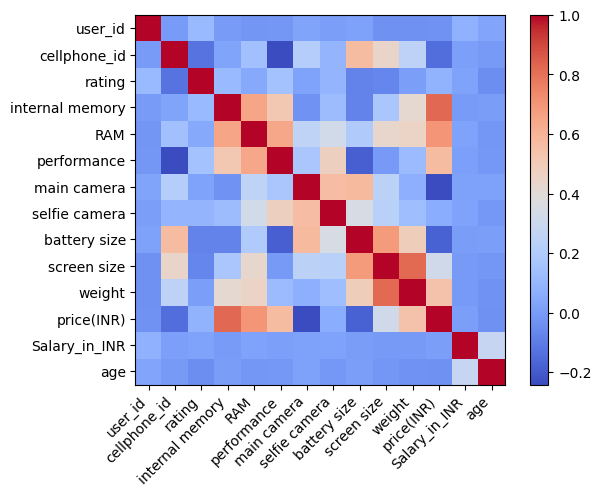

In [140]:
#Correlation Heatmap of Numerical Variables
corr = numerical_vars.corr()

plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

## Create count plots for all categorical variables to visualize their distributions.

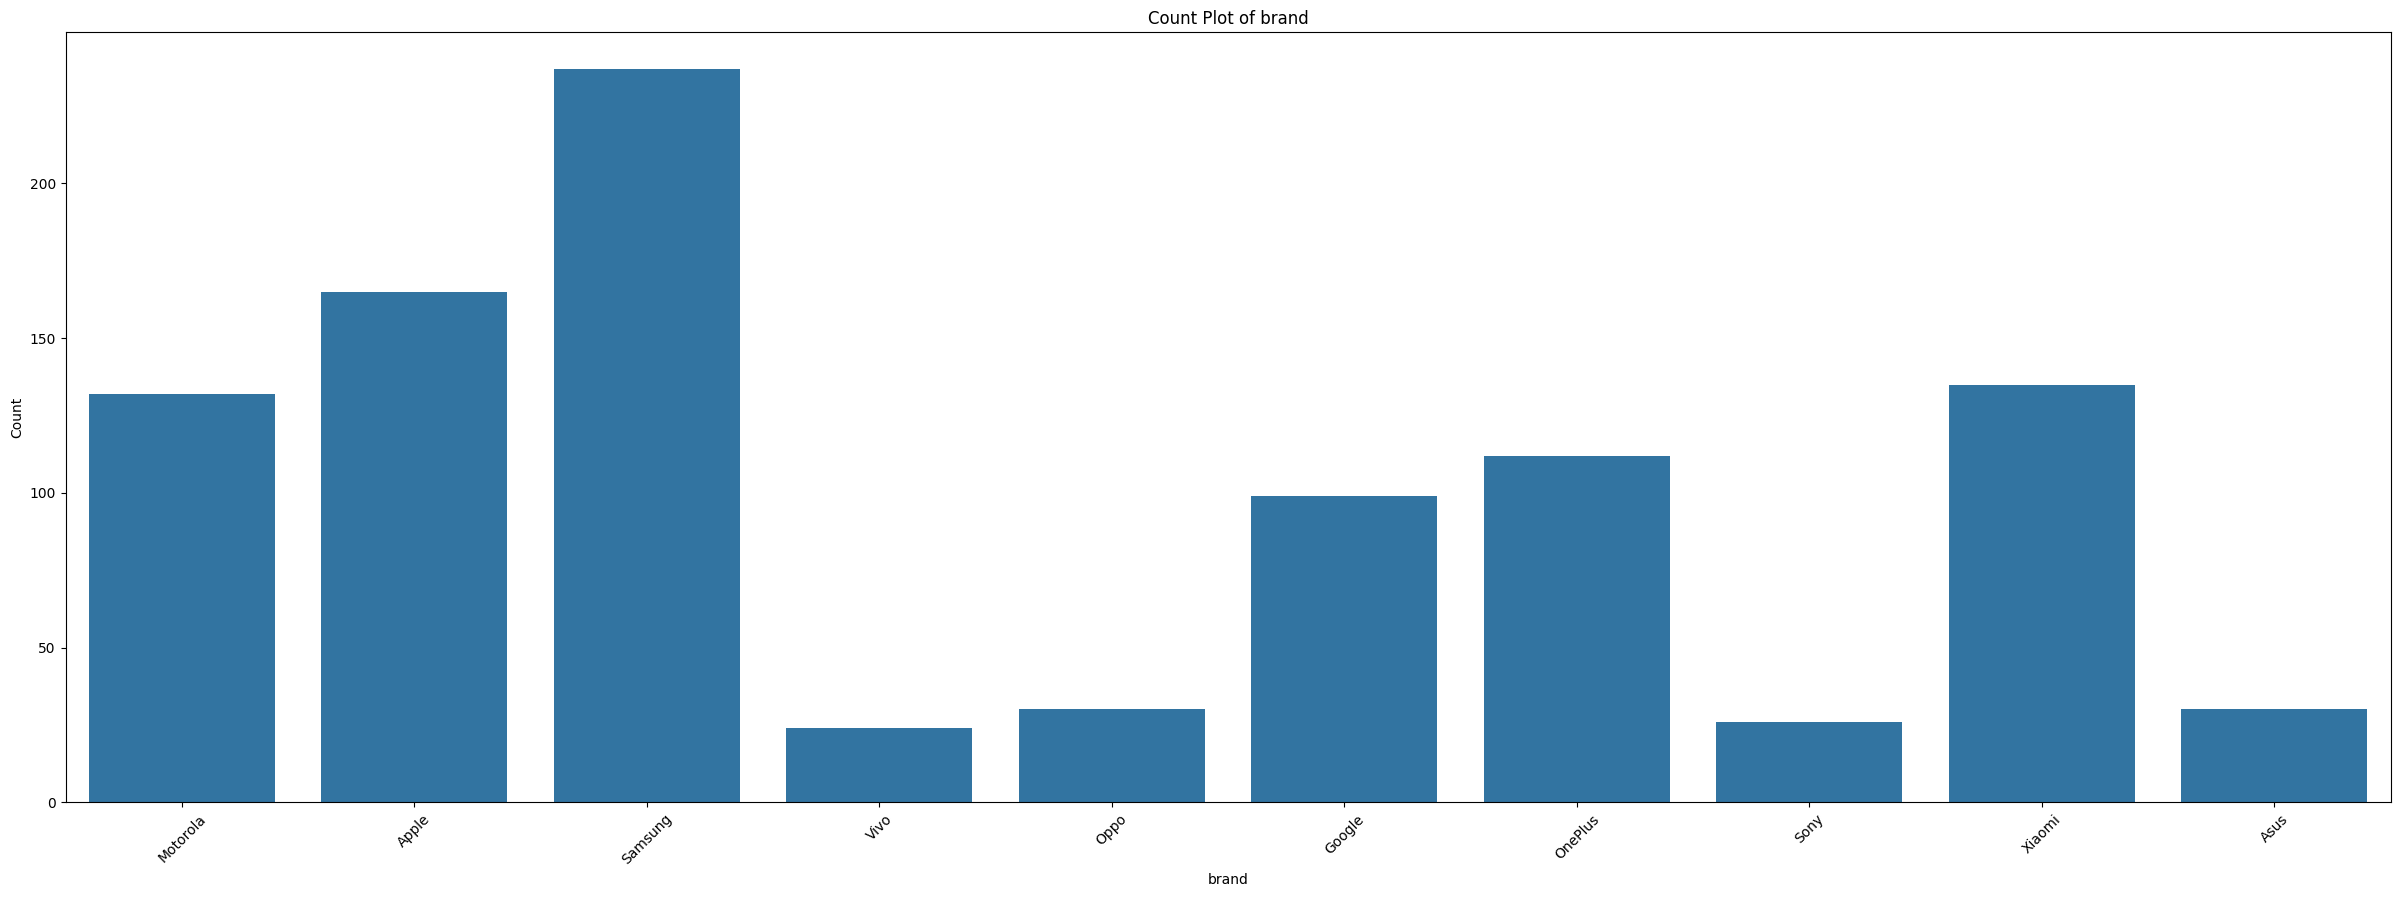

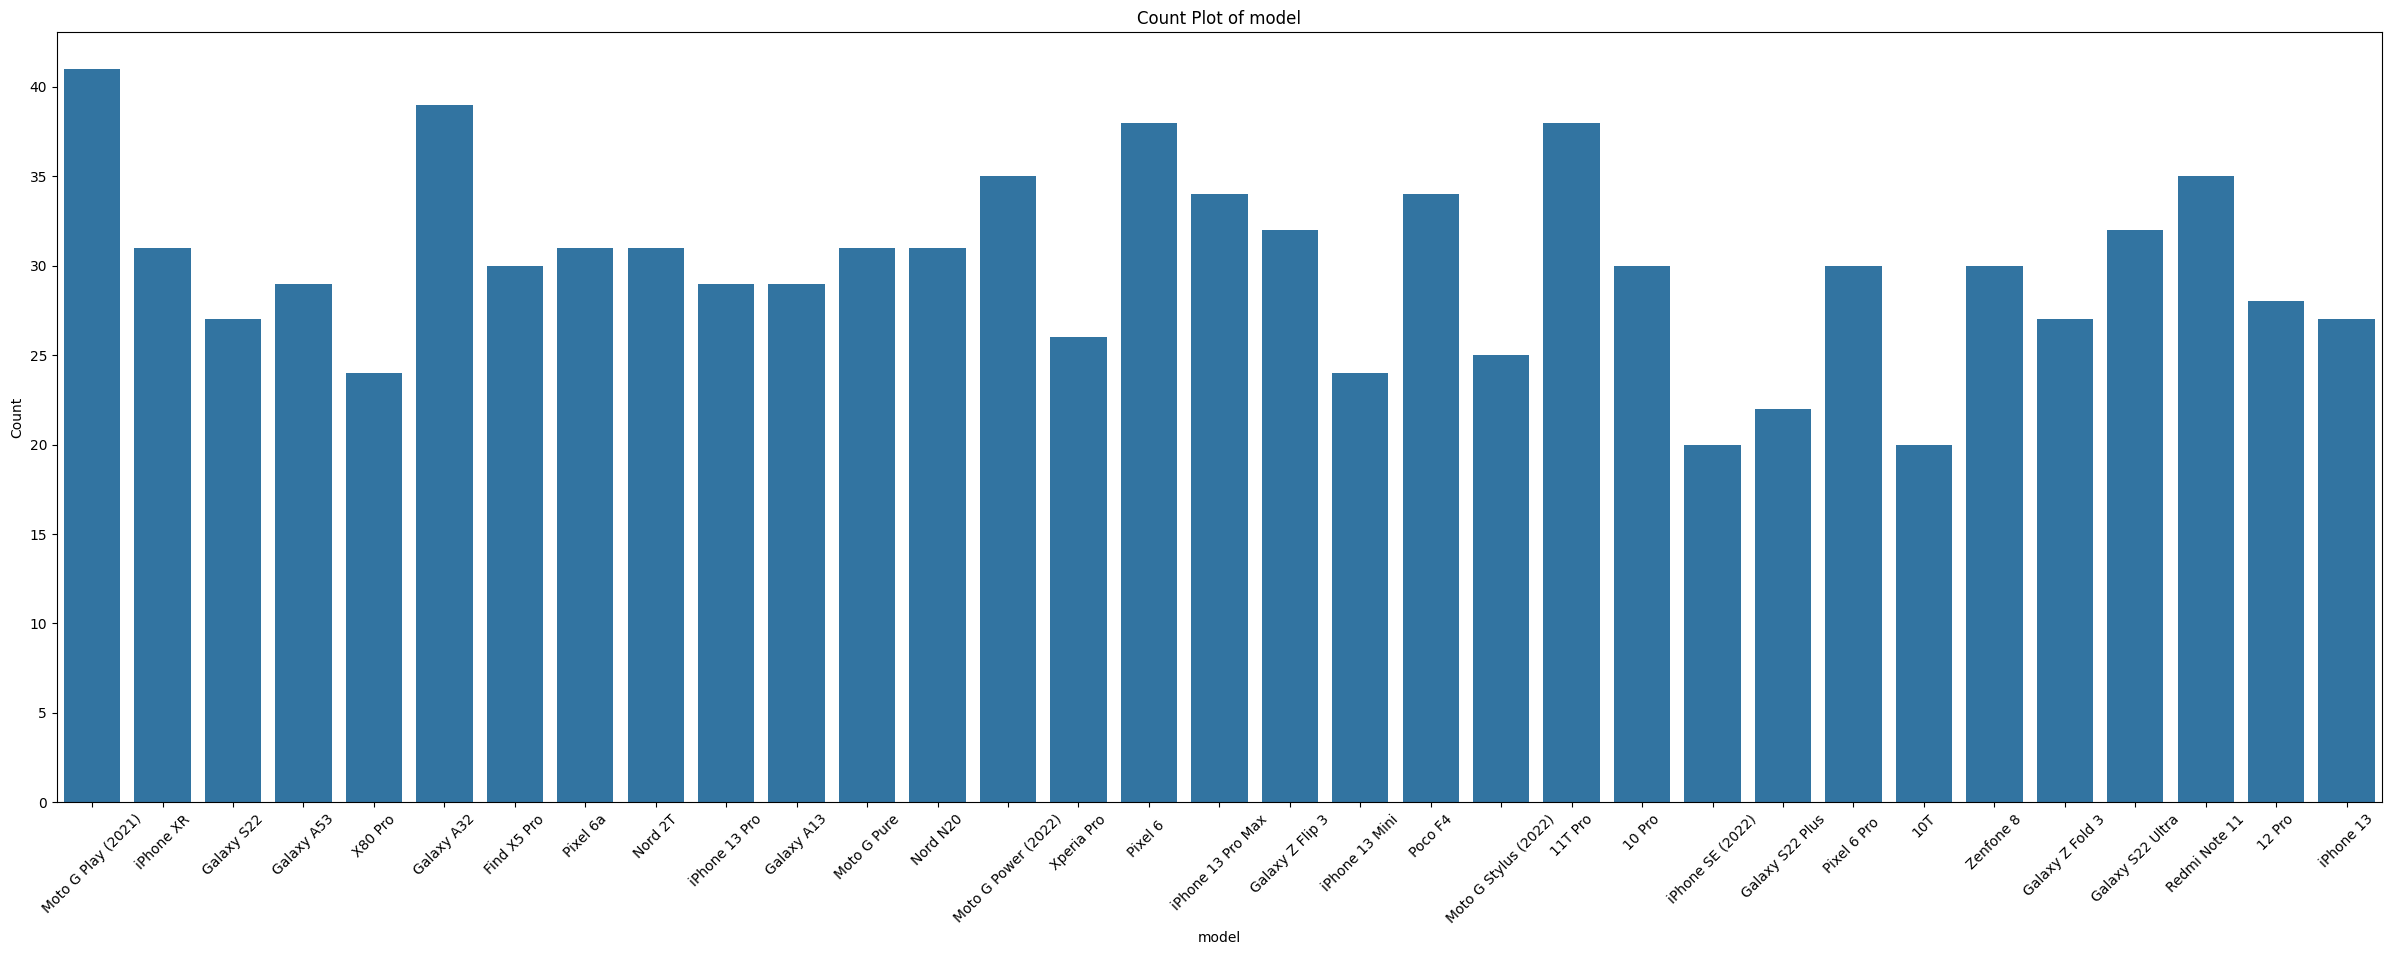

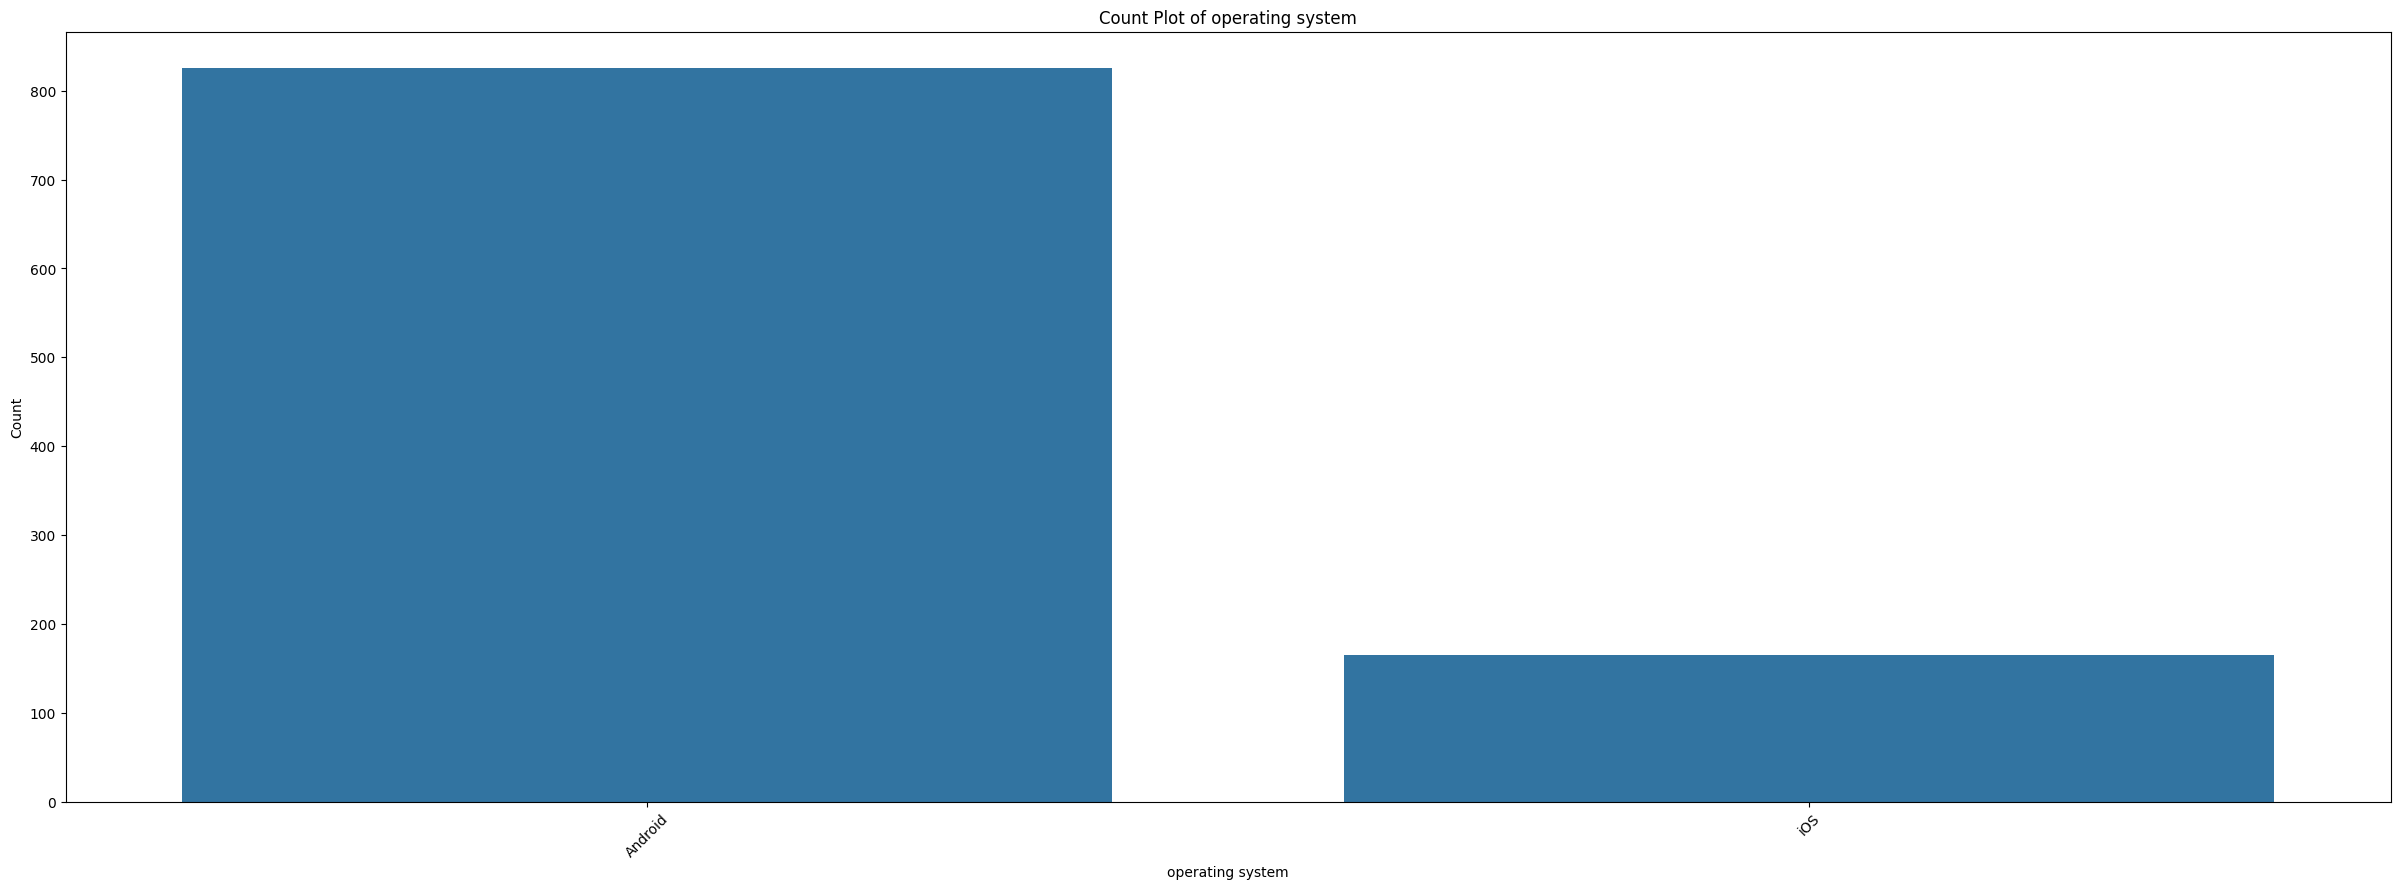

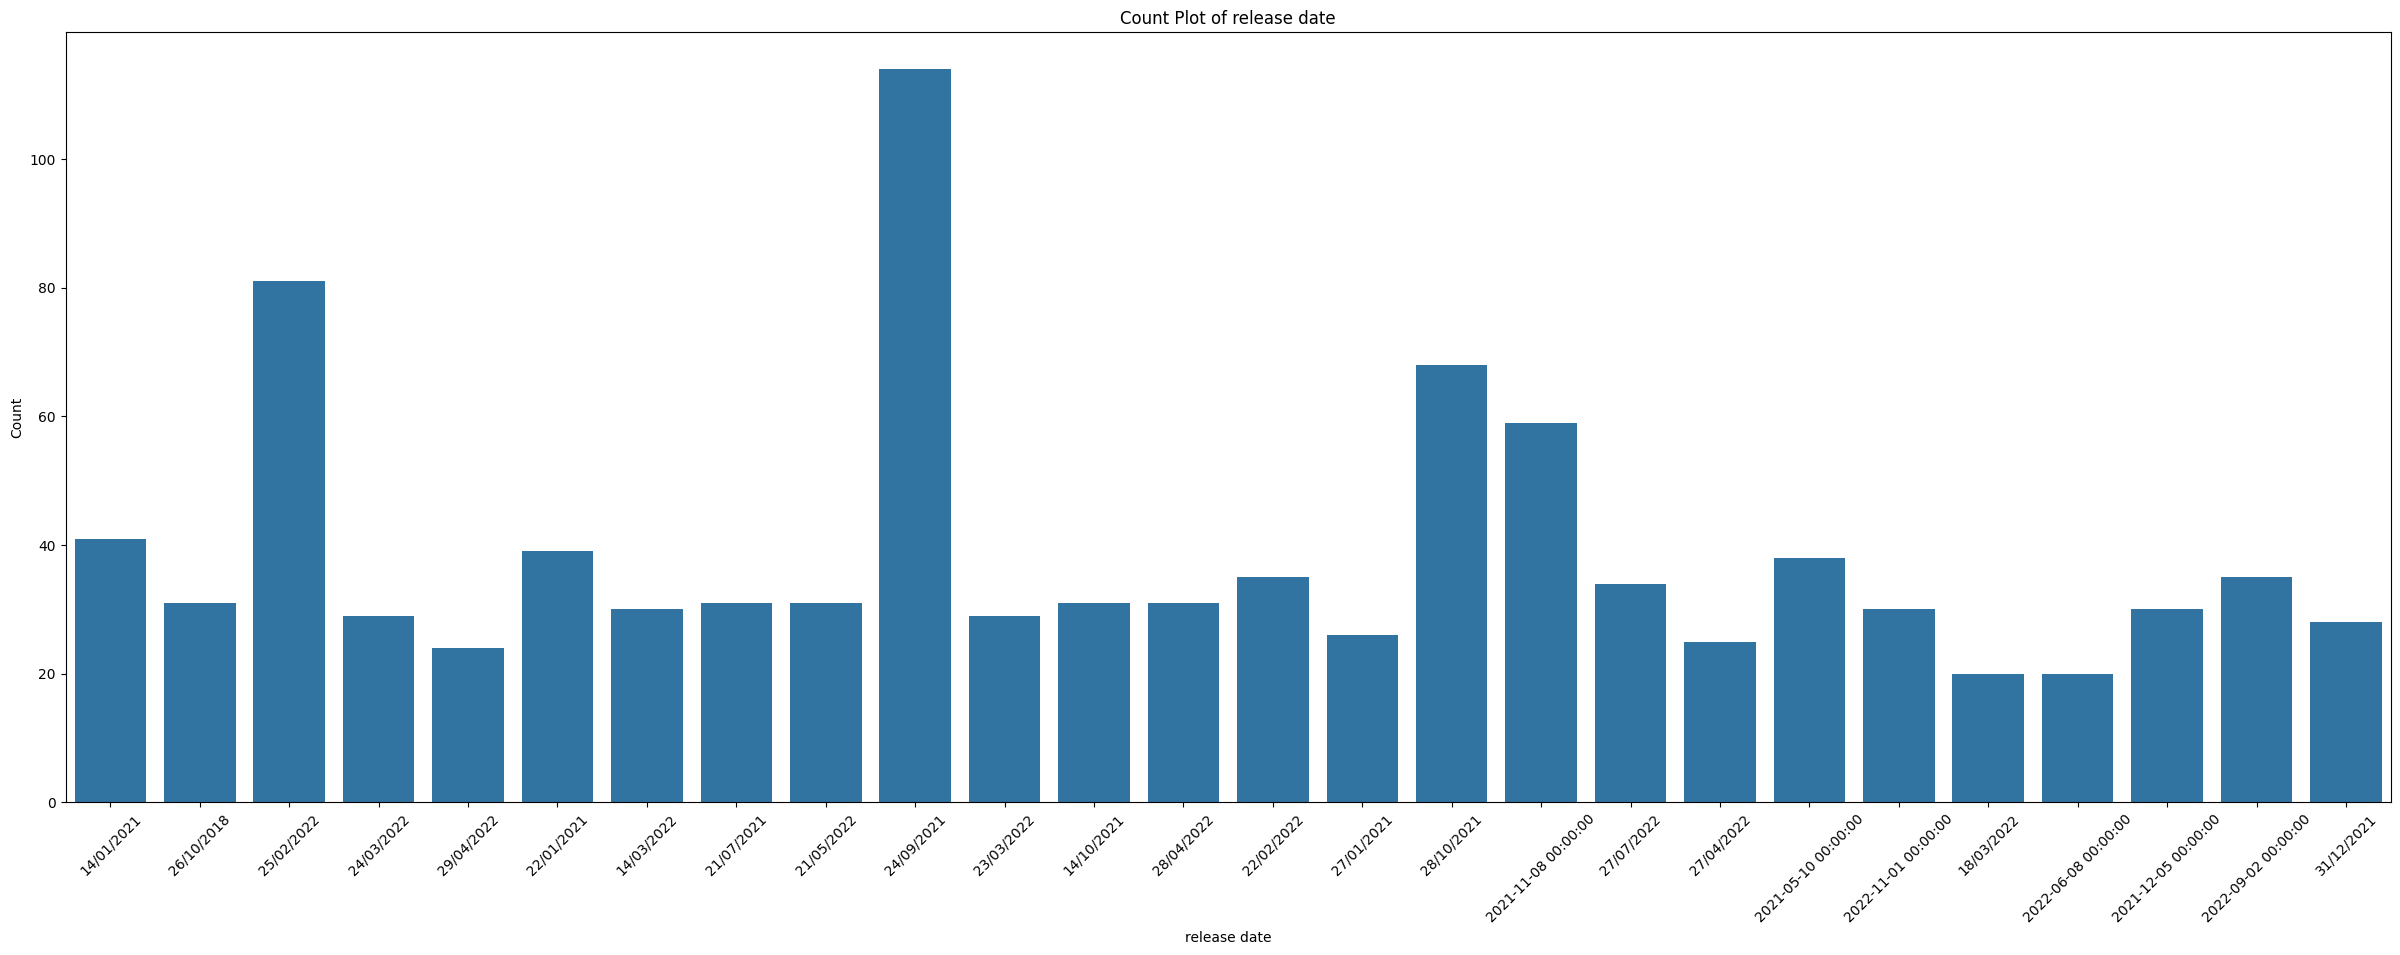

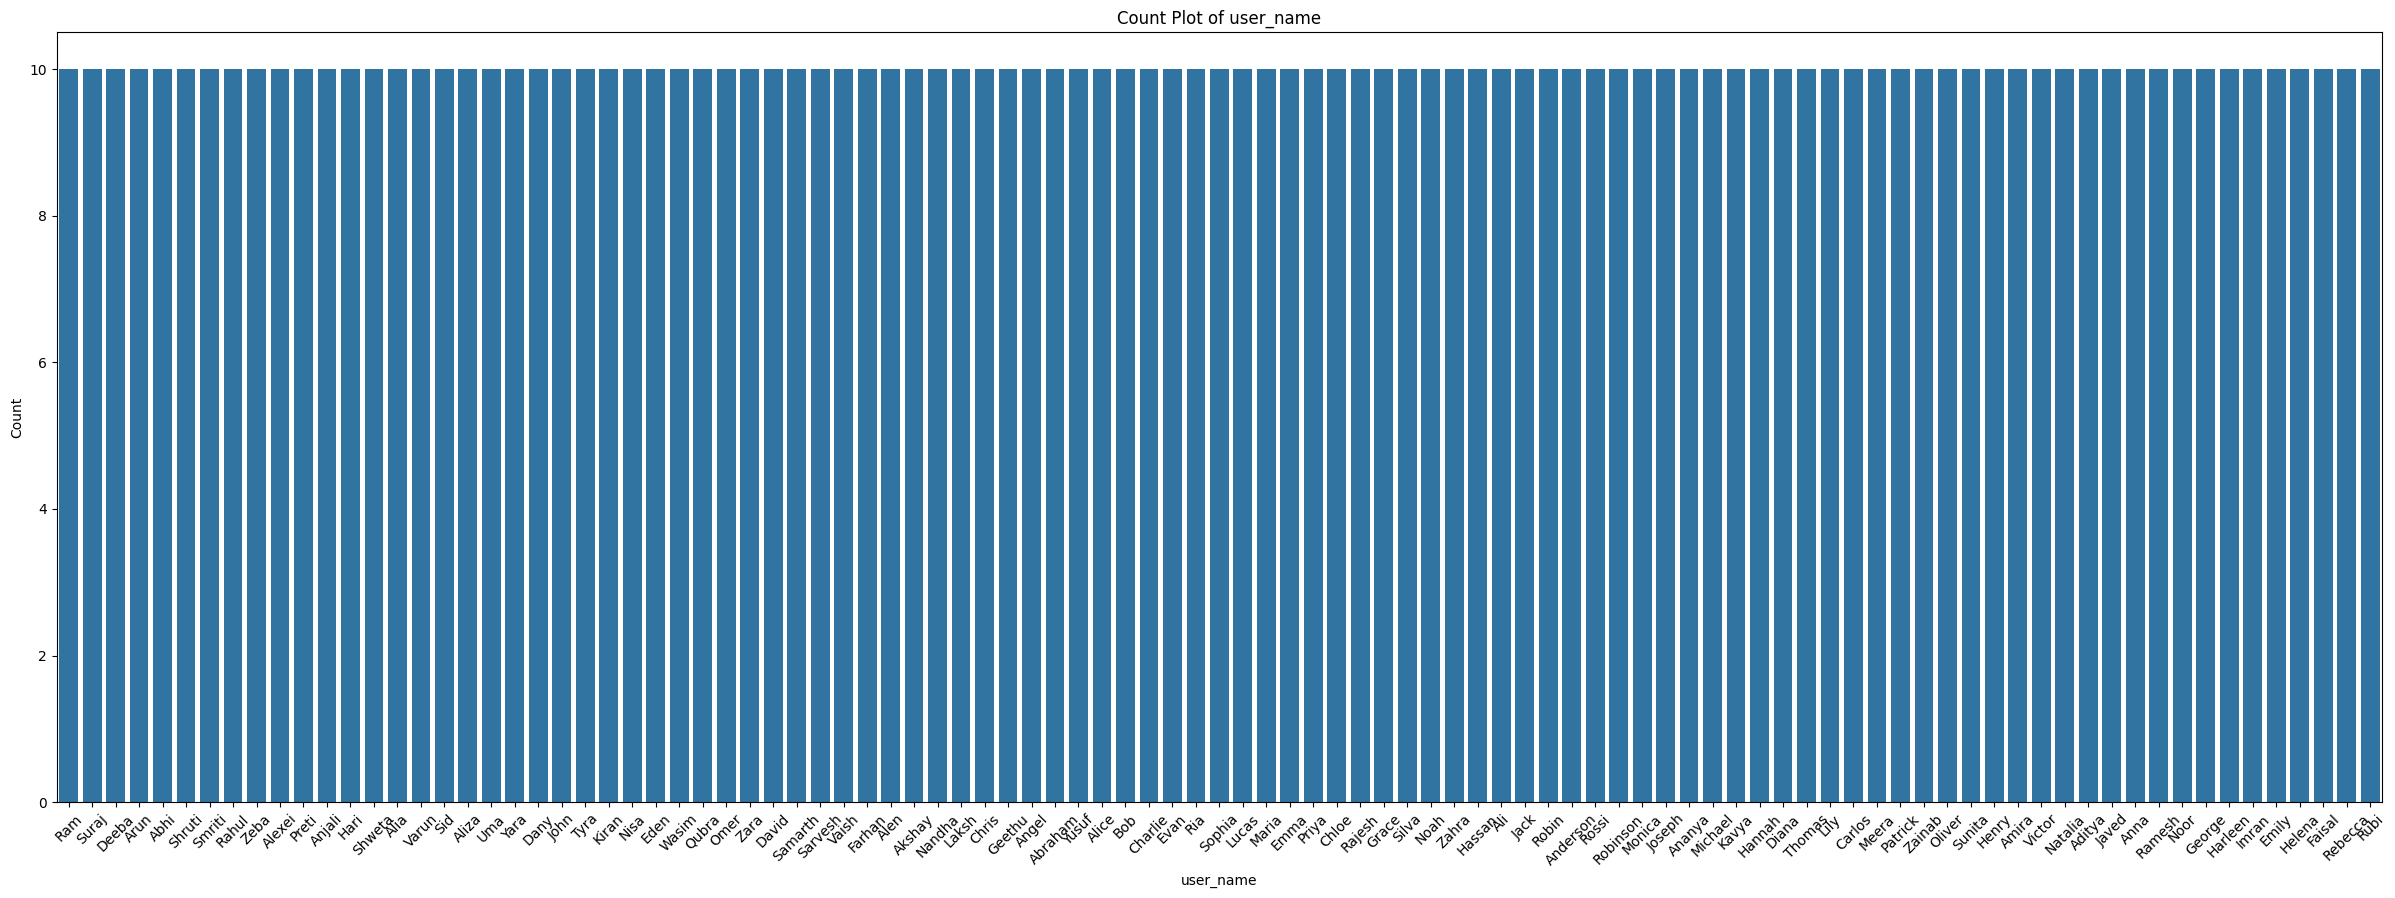

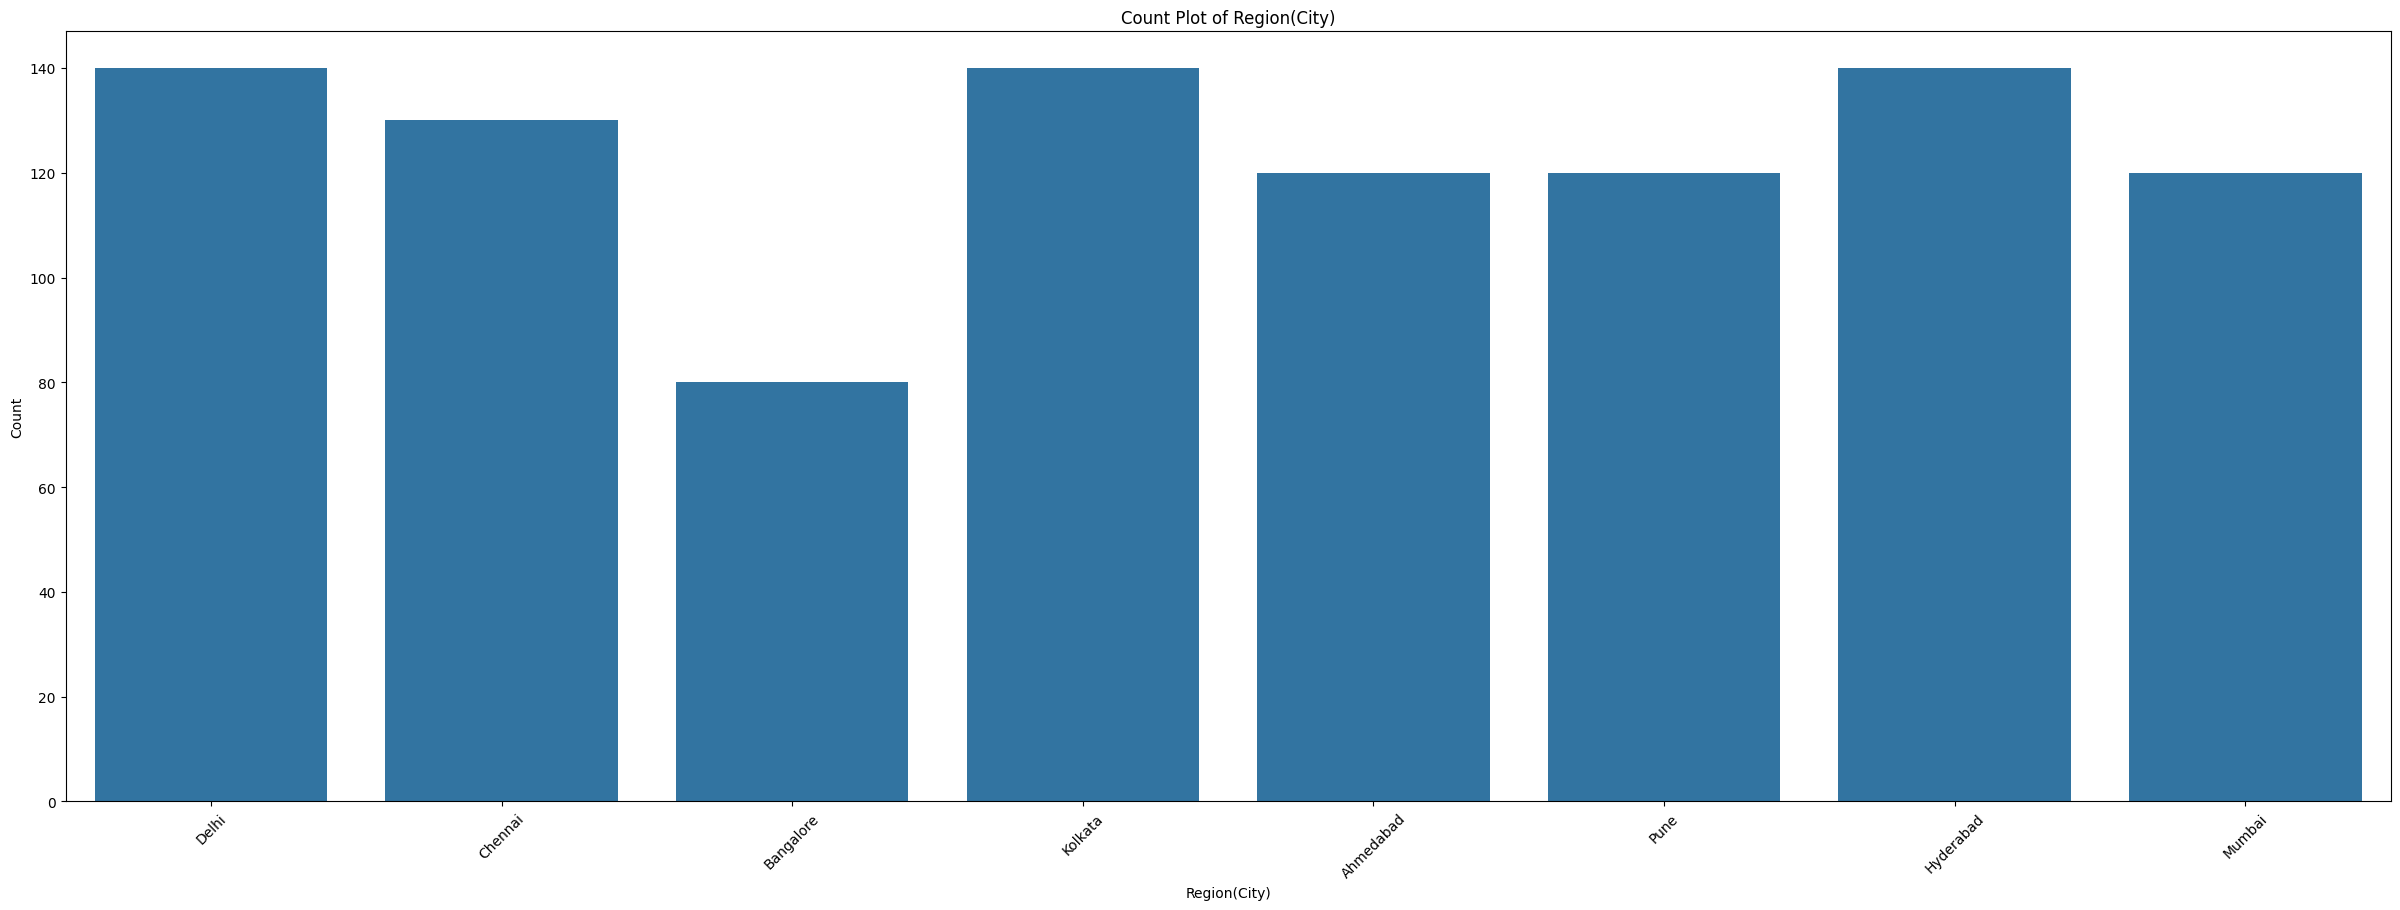

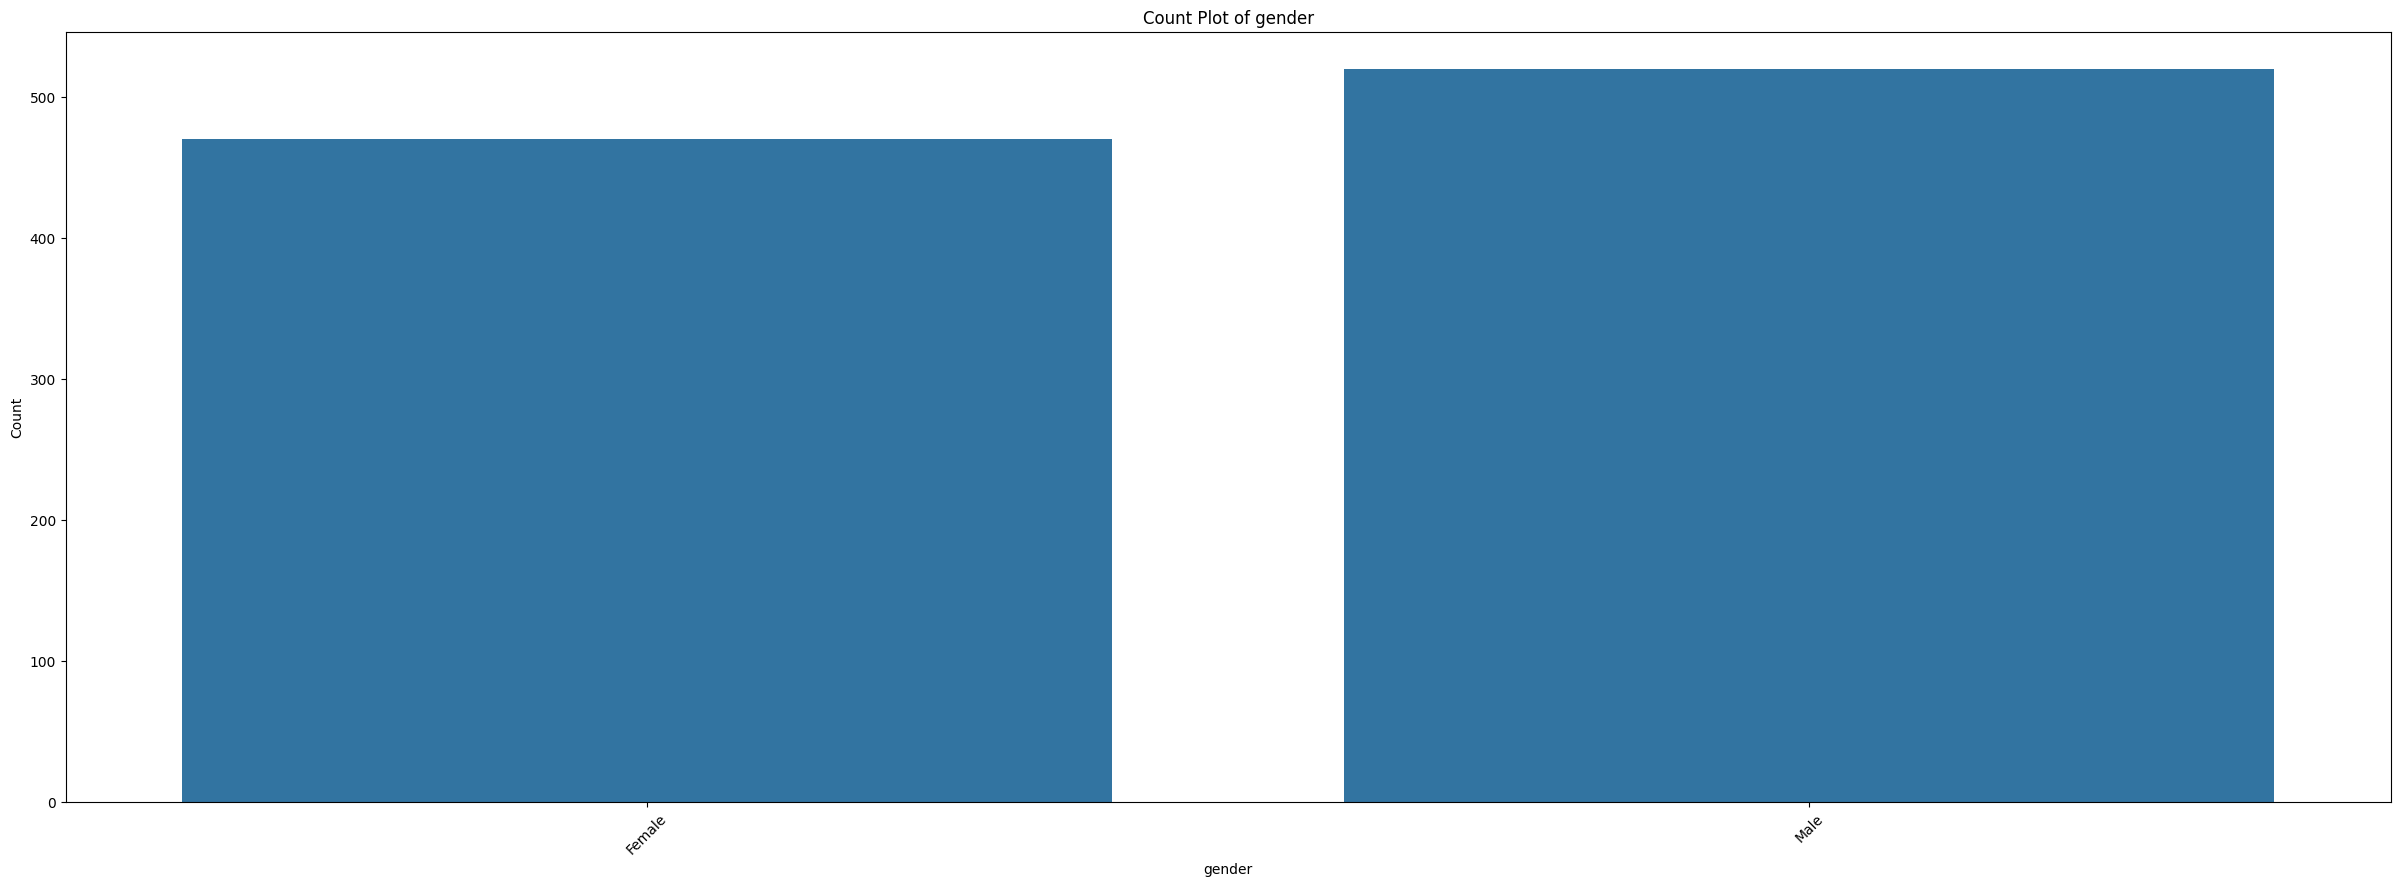

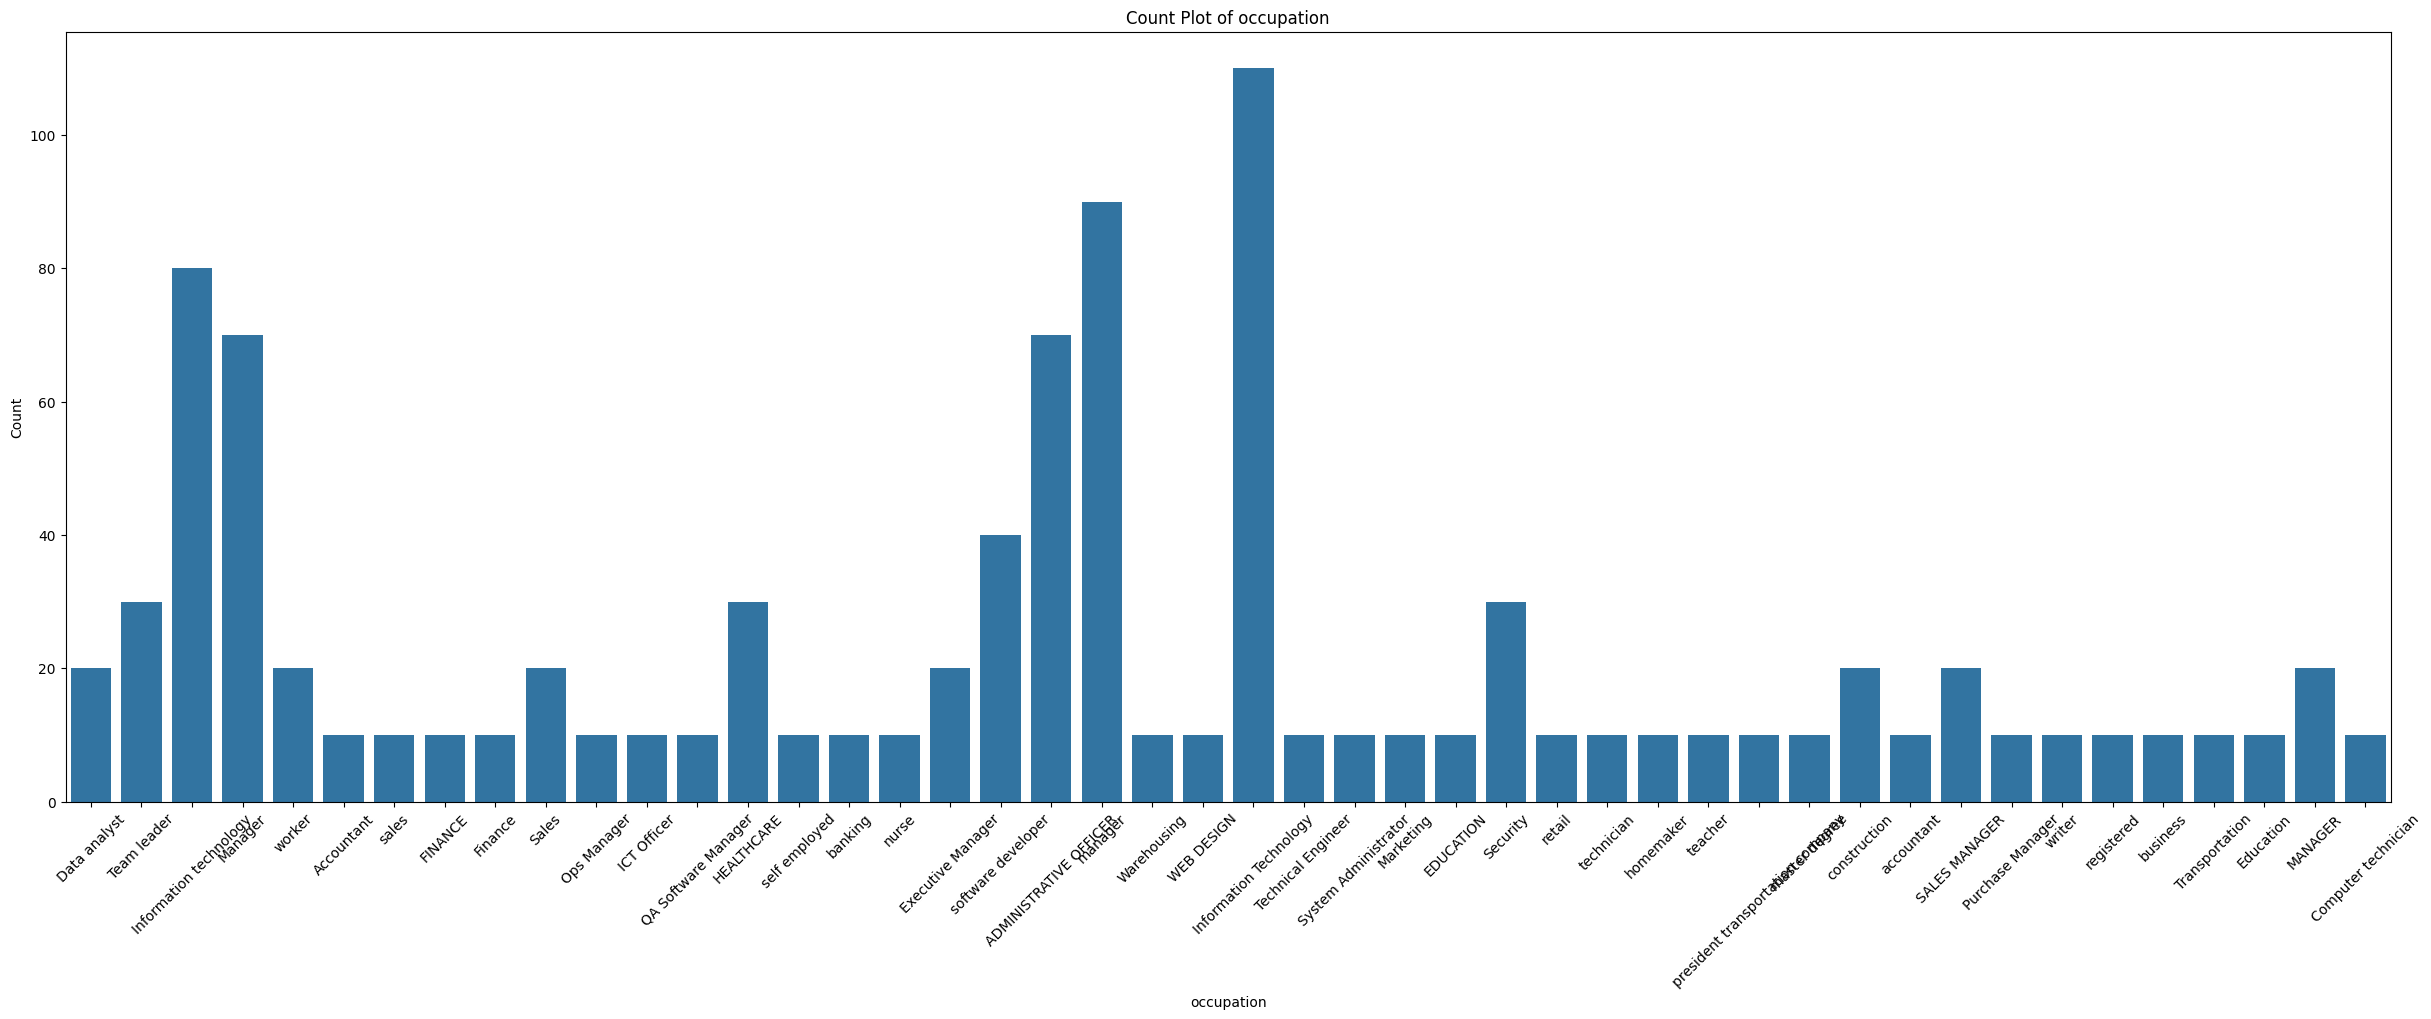

In [141]:
#Count Plot for all categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(30, 10))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

## Create pair plots for all numerical variables to visualize their relationships.

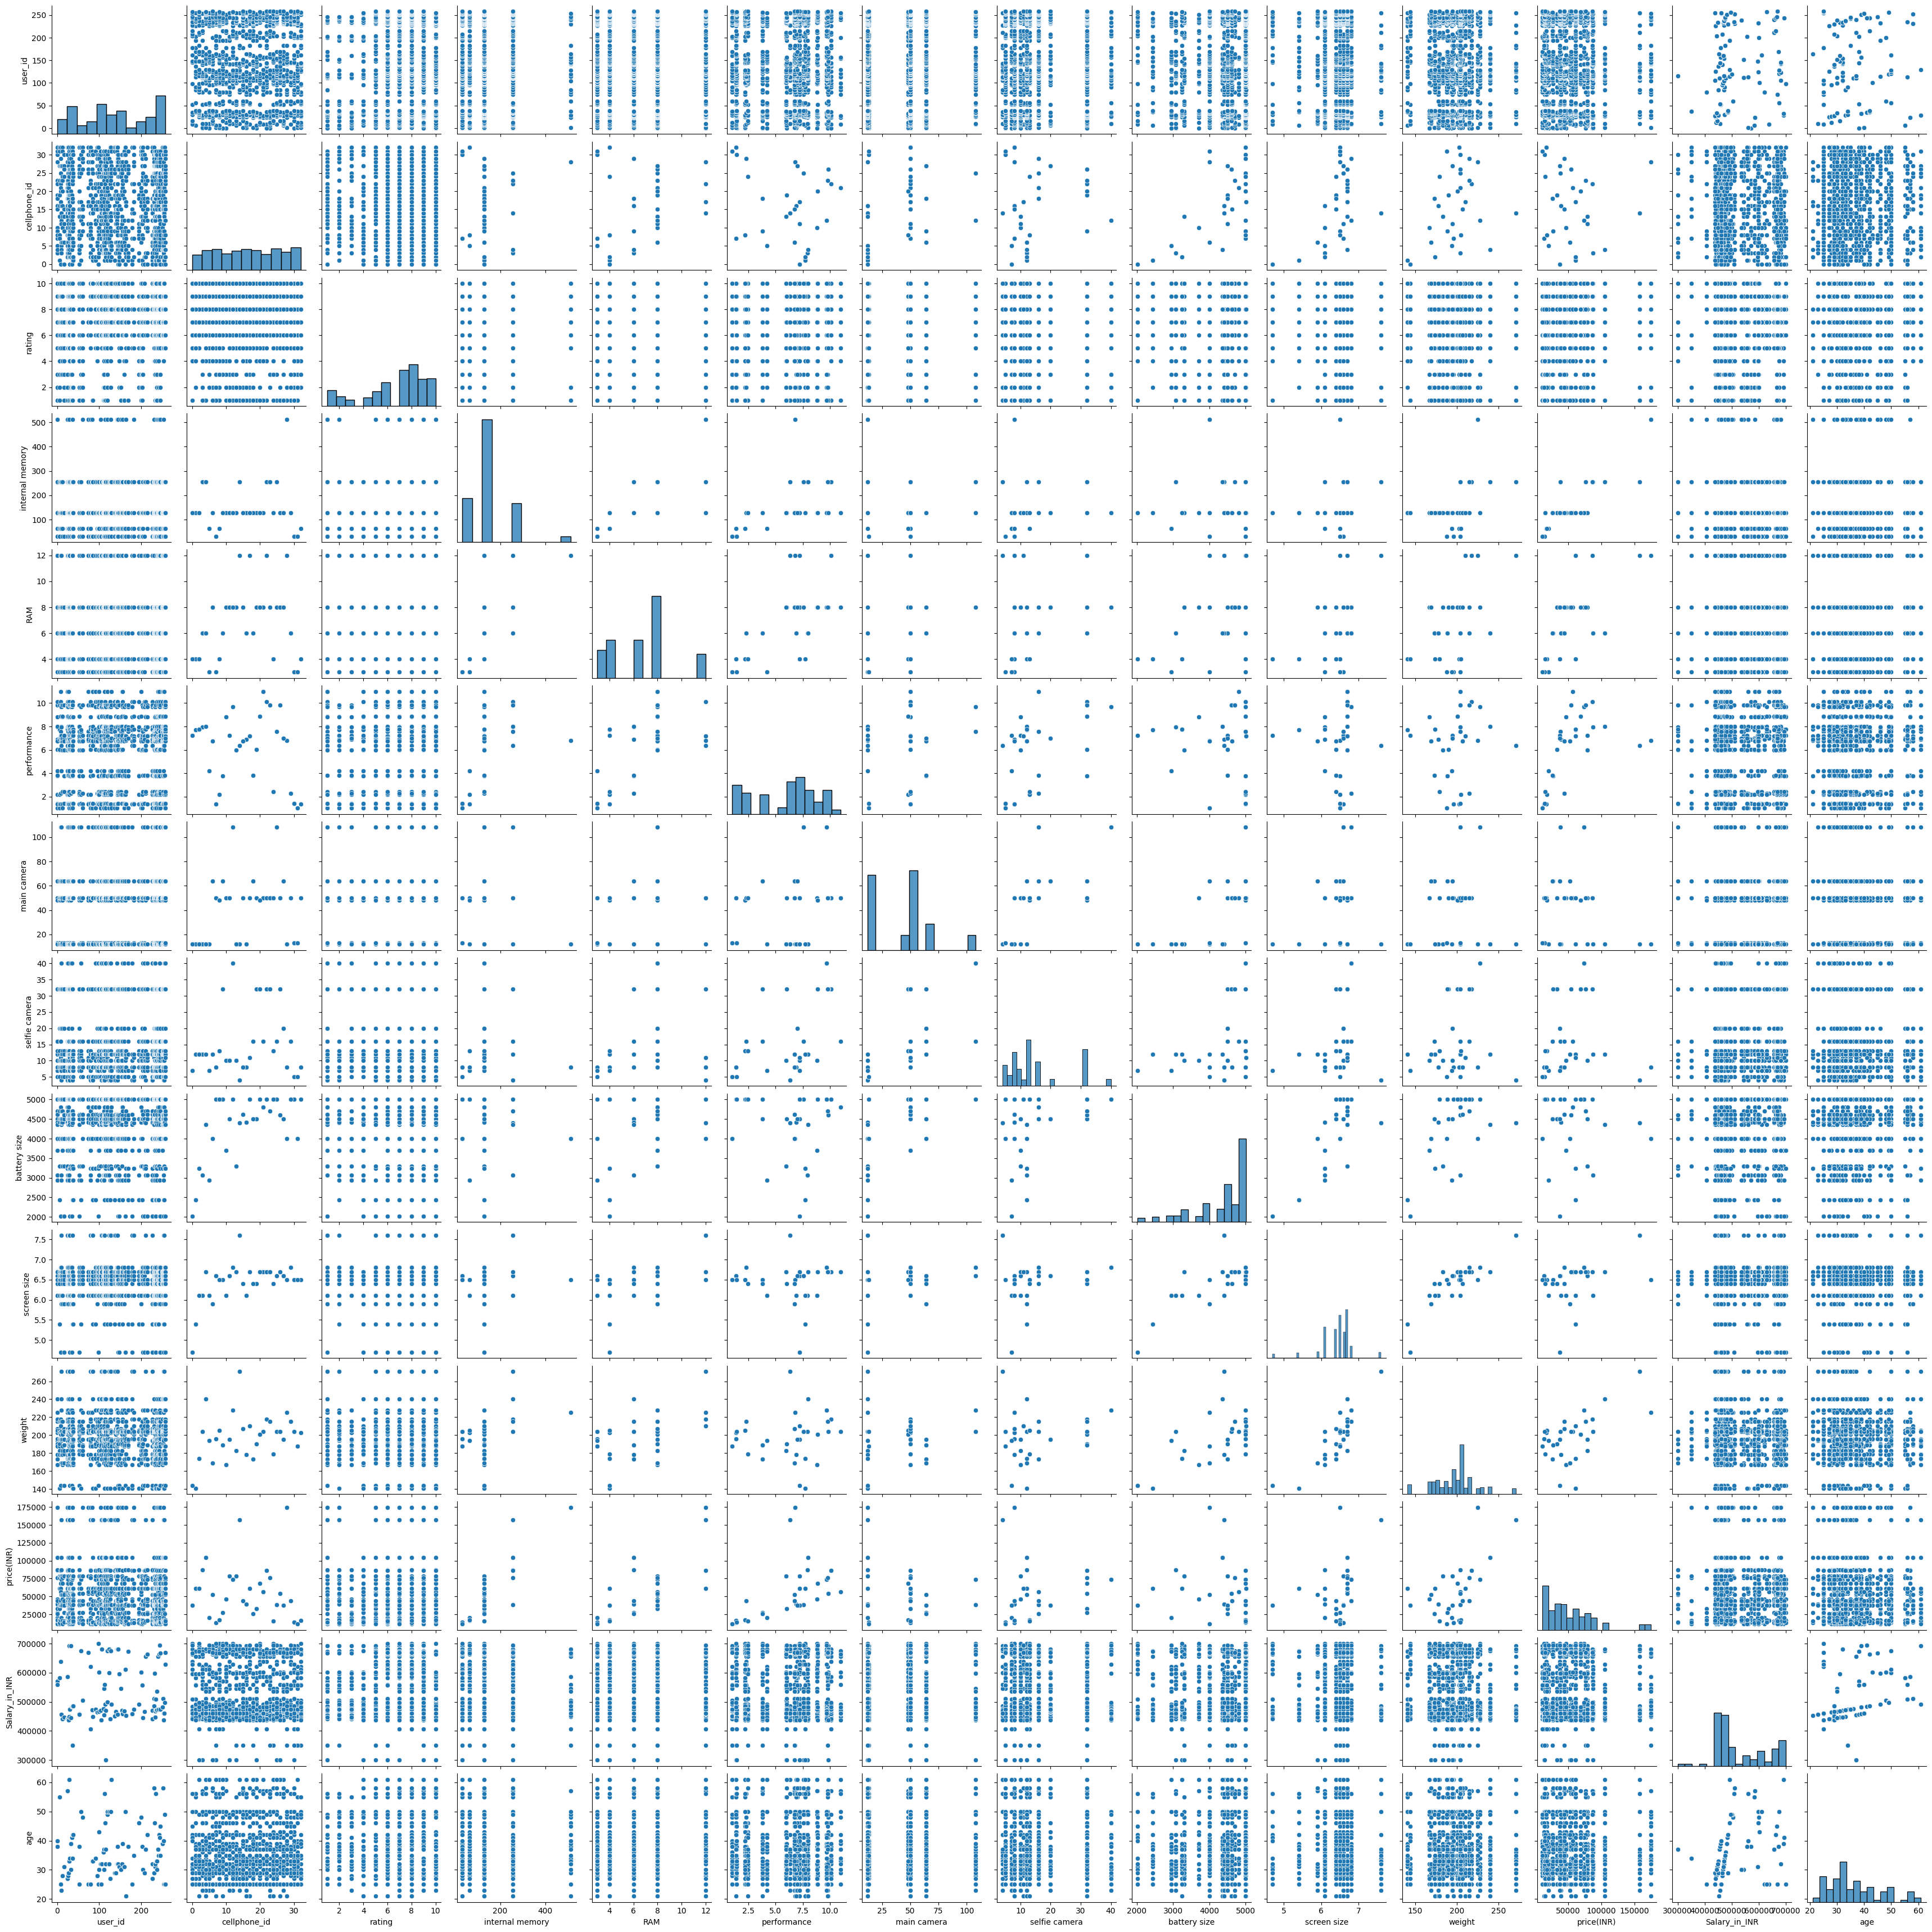

In [142]:
#Pair plot for all numerical variables
sns.pairplot(df[numerical_cols])
plt.show()

#### For the following all questions, replace the '_' with correct variable name according to question requirement

# 1. Hypothesis Testing

## 1a. Two-sample t-test: Salary difference between genders

In [143]:
male_salary = df[df['gender']=='Male']['Salary_in_INR']
female_salary = df[df['gender']=='Female']['Salary_in_INR']
t_stat, p_value = stats.ttest_ind(male_salary, female_salary)
print("T-test: Salary difference between genders")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

T-test: Salary difference between genders
t-statistic: -2.247686529084287 p-value: 0.024816102588423032 



## 1b. One-sample t-test: RAM > 16 GB

In [144]:
t_stat, p_value = stats.ttest_1samp(df['RAM'], 16, alternative='greater')
print("One-sample t-test: Mean RAM > 16 GB")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

One-sample t-test: Mean RAM > 16 GB
t-statistic: -109.71494869112836 p-value: 1.0 



## 1c. One-sample t-test: Main camera > 12 MP


In [145]:
t_stat, p_value = stats.ttest_1samp(df['main camera'], 12, alternative='greater')
print("One-sample t-test: Main camera > 12 MP")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

One-sample t-test: Main camera > 12 MP
t-statistic: 35.6415218671936 p-value: 6.466166332868273e-180 



## 1d. Two-sample t-test: Price difference between Android and iOS

In [146]:
android_price = df[df['operating system']=='Android']['price(INR)']
ios_price = df[df['operating system']=='iOS']['price(INR)']
t_stat, p_value = stats.ttest_ind(android_price, ios_price)
print("T-test: Price difference between Android and iOS")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

T-test: Price difference between Android and iOS
t-statistic: -4.466996840290052 p-value: 8.848111231308473e-06 



## 1e. One-sample t-test: Selfie camera > 8 MP

In [147]:
t_stat, p_value = stats.ttest_1samp(df['selfie camera'], 8, alternative='greater')
print("One-sample t-test: Selfie camera > 8 MP")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

One-sample t-test: Selfie camera > 8 MP
t-statistic: 23.51346761866551 p-value: 9.08337997279999e-98 



## 1f. One-sample t-test: Battery size > 4000 mAh

In [148]:
t_stat, p_value = stats.ttest_1samp(df['battery size'], 4000, alternative='greater')
print("One-sample t-test: Battery size > 4000 mAh")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

One-sample t-test: Battery size > 4000 mAh
t-statistic: 15.508314925000109 p-value: 5.106907137628001e-49 



## 1g. Two-sample t-test: Salary difference across regions (Delhi vs Mumbai)

In [149]:
if 'Delhi' in df['Region(City)'].unique() and 'Mumbai' in df['Region(City)'].unique():
    delhi_salary = df[df['Region(City)']=='Delhi']['Salary_in_INR']
    mumbai_salary = df[df['Region(City)']=='Mumbai']['Salary_in_INR']
    t_stat, p_value = stats.ttest_ind(delhi_salary, mumbai_salary)
    print("T-test: Salary difference between Delhi and Mumbai")
    print("t-statistic:", t_stat, "p-value:", p_value, "\n")

T-test: Salary difference between Delhi and Mumbai
t-statistic: -3.7216214193802313 p-value: 0.0002429934026022267 



# 2. ANOVA Tests

## 2a. Price difference across brands

In [150]:
brands_price = [df[df['brand']==b]['price(INR)'] for b in df['brand'].unique()]
f_stat, p_value = stats.f_oneway(*brands_price)
print("ANOVA: Price difference across brands")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: Price difference across brands
F-statistic: 105.6938582813186 p-value: 8.400100625599546e-138 



## 2b. Price difference across occupations

In [151]:
occupations_price = [df[df['occupation']==o]['price(INR)'] for o in df['occupation'].unique()]
f_stat, p_value = stats.f_oneway(*occupations_price)
print("ANOVA: Price difference across occupations")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: Price difference across occupations
F-statistic: 0.8784287384499441 p-value: 0.6994122934463652 



## 2c. Performance rating across age groups (<30, 30-50, >50)

In [152]:
group1 = df[df['age']<30]['performance']
group2 = df[(df['age']>=30) & (df['age']<=50)]['performance']
group3 = df[df['age']>50]['performance']
f_stat, p_value = stats.f_oneway(group1, group2, group3)
print("ANOVA: Performance rating across age groups")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: Performance rating across age groups
F-statistic: 0.2346328250662231 p-value: 0.7909052803742103 



## 2d. Battery size across brands

In [153]:
brands_battery = [df[df['brand']==b]['battery size'] for b in df['brand'].unique()]
f_stat, p_value = stats.f_oneway(*brands_battery)
print("ANOVA: Battery size difference across brands")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: Battery size difference across brands
F-statistic: 168.5946057117773 p-value: 3.4464217628758763e-192 



## 2e. Screen size across operating systems

In [154]:
os_screen = [df[df['operating system']==os]['screen size'] for os in df['operating system'].unique()]
f_stat, p_value = stats.f_oneway(*os_screen)
print("ANOVA: Screen size difference across OS")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: Screen size difference across OS
F-statistic: 389.8499802629494 p-value: 2.0973660013187365e-73 



## 2g. RAM across operating systems

In [155]:
os_ram = [df[df['operating system']==os]['RAM'] for os in df['operating system'].unique()]
f_stat, p_value = stats.f_oneway(*os_ram)
print("ANOVA: RAM difference across OS")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: RAM difference across OS
F-statistic: 143.9235786733912 p-value: 4.7164275665302215e-31 



## 2h. Main camera across brands

In [156]:
brands_camera = [df[df['brand']==b]['main camera'] for b in df['brand'].unique()]
f_stat, p_value = stats.f_oneway(*brands_camera)
print("ANOVA: Main camera difference across brands")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: Main camera difference across brands
F-statistic: 104.0043901548866 p-value: 3.926038714282027e-136 



# 3. Chi-Square Tests

## 3a. OS choice vs gender

In [128]:
os_gender_table = pd.crosstab(df['operating system'], df['gender'])
chi2, p, dof, expected = stats.chi2_contingency(os_gender_table)
print("Chi-square: OS choice vs Gender")
print("Chi2:", chi2, "p-value:", p, "\n")

Chi-square: OS choice vs Gender
Chi2: 0.0008101472995090708 p-value: 0.9772928087087882 



## 3b. Brand choice vs OS

In [129]:
brand_os_table = pd.crosstab(df['brand'], df['operating system'])
chi2, p, dof, expected = stats.chi2_contingency(brand_os_table)
print("Chi-square: Brand vs OS")
print("Chi2:", chi2, "p-value:", p, "\n")

Chi-square: Brand vs OS
Chi2: 989.9999999999999 p-value: 2.470476980705389e-207 



## 3c. Brand choice vs occupation

In [130]:
brand_occ_table = pd.crosstab(df['brand'], df['occupation'])
chi2, p, dof, expected = stats.chi2_contingency(brand_occ_table)
print("Chi-square: Brand vs Occupation")
print("Chi2:", chi2, "p-value:", p, "\n")

Chi-square: Brand vs Occupation
Chi2: 284.84565845452767 p-value: 0.9999987418741012 

